In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
dry_bean = fetch_ucirepo(id=602) 
  
# data (as pandas dataframes) 
X = dry_bean.data.features 
y = dry_bean.data.targets 
  
# metadata 
print(dry_bean.metadata) 
  
# variable information 
print(dry_bean.variables) 


{'uci_id': 602, 'name': 'Dry Bean', 'repository_url': 'https://archive.ics.uci.edu/dataset/602/dry+bean+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/602/data.csv', 'abstract': 'Images of 13,611 grains of 7 different registered dry beans were taken with a high-resolution camera. A total of 16 features; 12 dimensions and 4 shape forms, were obtained from the grains.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 13611, 'num_features': 16, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Thu Mar 28 2024', 'dataset_doi': '10.24432/C50S4B', 'creators': [], 'intro_paper': {'ID': 244, 'type': 'NATIVE', 'title': 'Multiclass classification of dry beans using computer vision and machine learning techniques', 'authors': 'M. Koklu, Ilker Ali Özkan', 'venue': 'Co


▶ Dry Bean 데이터셋 MLP 학습 시작...
Epoch 1/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8471 - loss: 0.4543 - val_accuracy: 0.9115 - val_loss: 0.2319
Epoch 2/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9113 - loss: 0.2482 - val_accuracy: 0.9174 - val_loss: 0.2228
Epoch 3/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9194 - loss: 0.2269 - val_accuracy: 0.9199 - val_loss: 0.2141
Epoch 4/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9216 - loss: 0.2162 - val_accuracy: 0.9225 - val_loss: 0.2072
Epoch 5/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9195 - loss: 0.2153 - val_accuracy: 0.9210 - val_loss: 0.2066
Epoch 6/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9234 - loss: 0.2081 - val_accuracy: 0.9218 - val_loss: 0.2050
Epoch 7/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9248 - loss: 0.2052 - val_accuracy: 0.9232 - val_loss: 0.2055
Epoch 8/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9237 - l

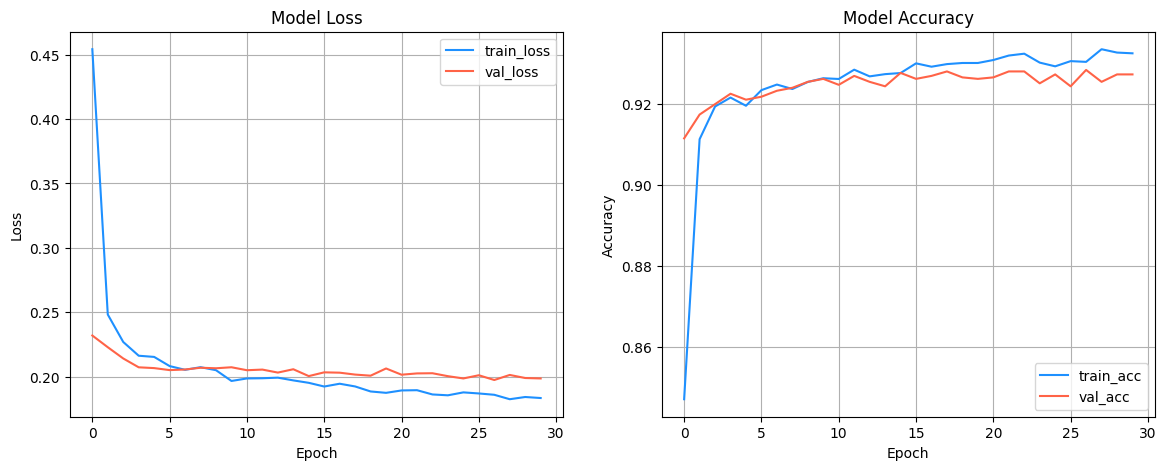

In [2]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

# 1. UCI 데이터셋 로드 (Dry Bean 데이터셋: ID 602)
dry_bean = fetch_ucirepo(id=602) 
X = dry_bean.data.features 
y = dry_bean.data.targets 

# 2. [전처리] LabelEncoder를 사용하여 문자열 타깃을 정수(0~6)로 변환
# 데이터셋의 문자열 품종('Seker', 'Barbunya' 등)을 숫자로 변경합니다.
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())

# 3. 데이터 분할 (8:2 비율, 품종 비율을 고르게 분할하기 위해 stratify 적용)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. [전처리] StandardScaler를 사용하여 피처 스케일링 수행
# 수만 단위의 Area(면적)와 0~1 사이의 Solidity(고형도)의 단위를 평균 0, 표준편차 1로 맞춥니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 5. 난수 시드 고정 및 세션 초기화 (동일 조건 보장)
keras.backend.clear_session()
keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

# 6. MLP 딥러닝 모델 설계
model = keras.Sequential()
# 표 형태의 데이터이므로 16개 피처를 나타내는 Input(shape=(16,)) 레이어를 사용합니다.
model.add(keras.layers.Input(shape=(16,)))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.3))  # 과대적합 방지를 위한 드롭아웃 적용
model.add(keras.layers.Dense(64, activation='relu'))

# [출력층] 품종이 7개이므로 뉴런 수는 7개, 다중 분류를 위해 활성화 함수는 softmax를 지정합니다.
model.add(keras.layers.Dense(7, activation='softmax'))

# 7. 모델 컴파일
# 타깃 값이 원-핫 인코딩(One-hot)이 아닌 정수형(0~6)이므로 sparse_categorical_crossentropy를 씁니다.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 8. 모델 학습 시작 (30 에포크)
print("▶ Dry Bean 데이터셋 MLP 학습 시작...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_scaled, y_val)
)

# 9. 최종 학습 결과 확인
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n[최종 결과] 훈련 정확도: {final_train_acc:.4f} | 검증 정확도: {final_val_acc:.4f}")

# 10. 손실 및 정확도 곡선 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 손실(Loss) 그래프
ax1.plot(history.history['loss'], label='train_loss', color='dodgerblue')
ax1.plot(history.history['val_loss'], label='val_loss', color='tomato')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# 정확도(Accuracy) 그래프
ax2.plot(history.history['accuracy'], label='train_acc', color='dodgerblue')
ax2.plot(history.history['val_accuracy'], label='val_acc', color='tomato')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()

### Random Forest가 더 좋은 상황 (빠르고 단순하게 고성능을 낼 때)
- 피처 스케일링이 필요 없고, 결측치나 이상치에 강하며, 하이퍼파라미터 튜닝 없이도 즉시 준수한 성능

▶ RF 학습 소요 시간: 0.35초
▶ RF 검증 정확도: 0.9218


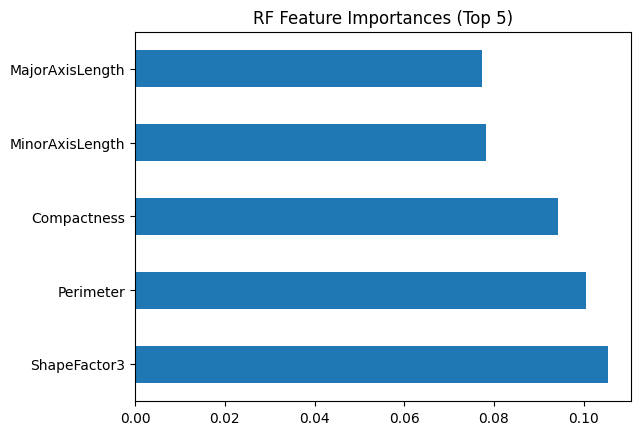

In [3]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# 1. 데이터 로드 (스케일링 생략)
dry_bean = fetch_ucirepo(id=602) 
X = dry_bean.data.features 
y = dry_bean.data.targets.values.ravel()  # 문자열 타깃 그대로 사용 가능

# 2. 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 모델 생성 및 학습 (CPU만으로 몇 초 만에 완료)
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print(f"▶ RF 학습 소요 시간: {time.time() - start_time:.2f}초")

# 4. 성능 평가 및 특성 중요도 확인 (결과 설명 가능)
y_pred = rf_model.predict(X_val)
print(f"▶ RF 검증 정확도: {accuracy_score(y_val, y_pred):.4f}")

# 어떤 피처가 품종 분류에 중요했는지 바로 시각화 가능
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh')
plt.title("RF Feature Importances (Top 5)")
plt.show()

### MLP가 더 좋은 상황 (복잡한 데이터에서 최상의 한계를 시험할 때)

In [4]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import keras
import tensorflow as tf

# 1. 데이터 로드
dry_bean = fetch_ucirepo(id=602) 
X = dry_bean.data.features 
y = dry_bean.data.targets 

# 2. 엄격한 전처리 (문자열 숫자로 변환, 데이터 스케일링 필수)
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 3. 정교한 네트워크 설계 (BatchNormalization, Dropout 레이어 혼합)
keras.backend.clear_session()
keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(16,)),
    
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),  # 안정적인 학습을 위한 배치 정규화
    keras.layers.Dropout(0.3),          # 과대적합 방지
    
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Dense(7, activation='softmax')  # 7개 클래스 확률 출력
])

# 4. 컴파일 및 최적의 가중치를 위한 콜백 설정
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# 5. 복잡한 패턴 반복 학습
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping],
    verbose=0
)

# 6. 성능 평가
final_loss, final_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"▶ MLP 검증 정확도: {final_acc:.4f}")

▶ MLP 검증 정확도: 0.9273
